In [8]:
!pip install xgboost
!pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [1]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd "/content/drive/MyDrive/telecom"

/content/drive/MyDrive/telecom


In [4]:
import os
from pathlib import Path

# current_dir is already /content/drive/MyDrive/telecom
current_dir = Path(os.getcwd())
client_path = current_dir / "Client.csv"
record_path = current_dir / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/telecom/Client.csv
OK  /content/drive/MyDrive/telecom/Record.csv


In [11]:
record_df = pd.read_csv("Record.csv")
client_df = pd.read_csv("Client.csv")

df = record_df.merge(client_df, on="Customer_ID", how="inner")
df = df.drop(columns=["Customer_ID"])

TARGET = "churn"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [12]:
df.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 99 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100

In [14]:
df.groupby('churn')[['drop_vce_Mean', 'blck_vce_Mean', 'drop_dat_Mean', 'blck_dat_Mean']].mean()

,drop_vce_Mean,blck_vce_Mean,drop_dat_Mean,blck_dat_Mean
churn,,,,
0,6.090553,4.118370,0.045931,0.031709
1,5.817222,3.925776,0.035013,0.019740


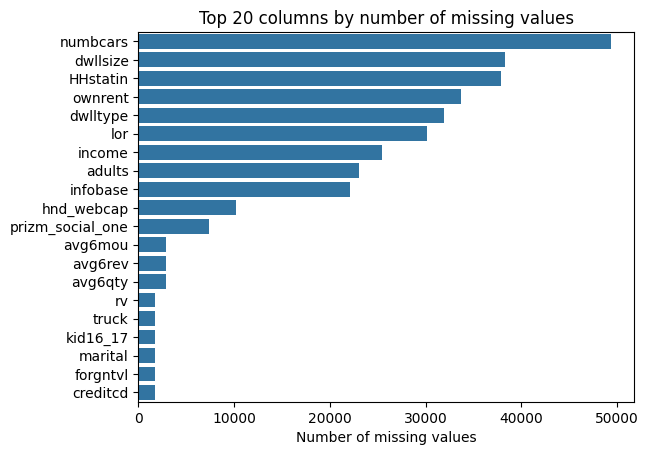

In [15]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.ylabel('')
plt.title('Top 20 columns by number of missing values')
plt.show()

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


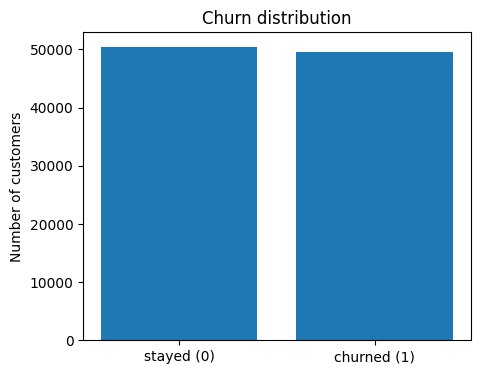

In [16]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


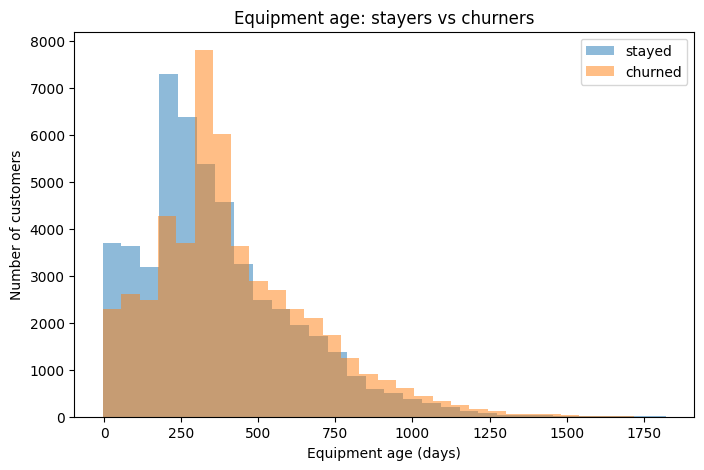

In [17]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

In [18]:
df.groupby('churn')[['change_mou', 'rev_Mean']].mean()

,change_mou,rev_Mean
churn,,
0,-5.344265,59.218692
1,-22.759003,58.211074


In [19]:
df.groupby('churn')[['custcare_Mean', 'cc_mou_Mean']].mean()

,custcare_Mean,cc_mou_Mean
churn,,
0,1.982599,4.051601
1,1.595688,3.308545


Minimum values before log transformation:
rev_Mean: -6.1675
mou_Mean: 0.0
totmrc_Mean: -26.915
eqpdays: -5.0


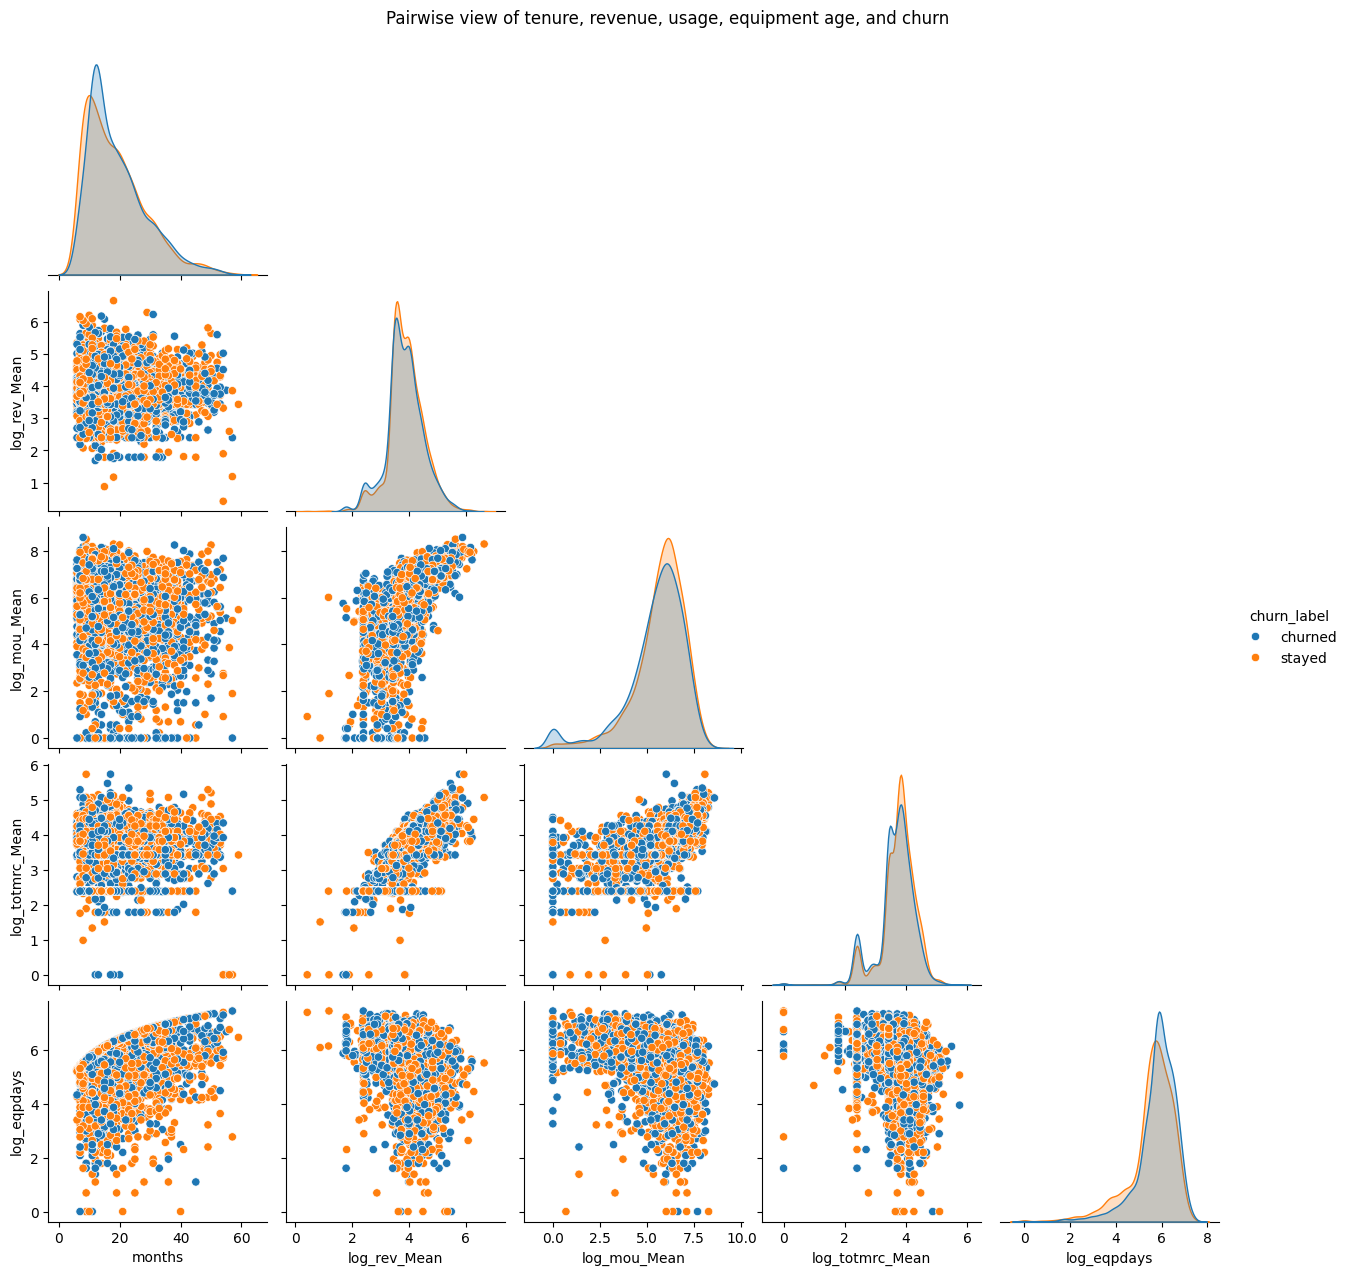

In [20]:
#Pairplot with log-transformed skewed variables

# Select relevant columns
plot_df = df[
    [
        'months',
        'rev_Mean',
        'mou_Mean',
        'totmrc_Mean',
        'eqpdays',
        'churn'
    ]
].dropna().copy()


# ============================================================
# Check minimum values before log transformation
# ============================================================

log_cols = [
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays'
]

print("Minimum values before log transformation:")

for col in log_cols:
    print(f"{col}: {plot_df[col].min()}")


# ============================================================
# Log-transform skewed variables
# ============================================================
# log1p(x) requires x >= -1.
# We clip negative values to 0 to avoid invalid log1p results.
# NOTE: This transformation is only for visualization.

for col in log_cols:
    plot_df[f'log_{col}'] = np.log1p(
        plot_df[col].clip(lower=0)
    )


# ============================================================
# Create readable churn labels
# ============================================================

plot_df['churn_label'] = plot_df['churn'].map({
    0: 'stayed',
    1: 'churned'
})


# ============================================================
# Select columns for Pairplot
# ============================================================

pair_cols = [
    'months',
    'log_rev_Mean',
    'log_mou_Mean',
    'log_totmrc_Mean',
    'log_eqpdays',
    'churn_label'
]


# ============================================================
# Sample 5,000 observations for faster visualization
# ============================================================

pair_sample = plot_df[
    pair_cols
].sample(
    n=5000,
    random_state=42
)


# ============================================================
# Create Pairplot
# ============================================================

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde'
)


# ============================================================
# Plot title
# ============================================================

plt.suptitle(
    'Pairwise view of tenure, revenue, usage, equipment age, and churn',
    y=1.02
)

plt.show()



# **Problem Definition & Strategic Objective**

The objective of this project is to solve the critical revenue leakage caused by customer churn within Company A. EDA highlights that churners are active, high-value spenders ($rev\_Mean \approx 58$) who show a silent usage drop ($change\_mou = -22.76$) combined with aging equipment ($eqpdays > 421\ days$) before leaving.Utilizing a Binary Classification ML task, we will predict customers at high risk of churning. Our proposal will ultimately recommend a Proactive Device Upgrade Campaign targeting high-value users with aging handsets, ensuring network resilience aligned with NTRA infrastructure updates, and securing retention budgets where they prevent the most financial damage.

In [24]:

df_clean = df.copy()

# **Feature Engineering**

In [25]:
# 1. Overage Expense Extraction (Financial Pain)
df_clean['total_overage_charge'] = df_clean['rev_Mean'] - df_clean['totmrc_Mean']

# 2. Pre-Upgrade Duration / Device Ownership Tenure
df_clean['device_generation_gap'] = (df_clean['months'] * 30.4) - df_clean['eqpdays']

# 3. Zero-Upgrade Flag
df_clean['never_upgraded'] = np.where(df_clean['device_generation_gap'] <= 5, 1, 0)

# 4. Plan Utilization Efficiency
df_clean['revenue_utilization_index'] = df_clean['mou_Mean'] / (df_clean['rev_Mean'] + 1)

# 5. Usage Churn Velocity
df_clean['silent_drop_indicator'] = df_clean['change_mou'] * (1 / (df_clean['custcare_Mean'] + 1))

# 6. Technical Frustration
df_clean['call_failure_rate'] = df_clean['drop_blk_Mean'] / (df_clean['attempt_Mean'] + 1)
df_clean['voice_drop_ratio'] = df_clean['drop_vce_Mean'] / (df_clean['plcd_vce_Mean'] + 1)

# 7. Behavioral Shifts (Momentum)
df_clean['relative_mou_momentum'] = df_clean['change_mou'] / (df_clean['avgmou'] + 1)
df_clean['relative_rev_momentum'] = df_clean['change_rev'] / (df_clean['avgrev'] + 1)

# 8. Cost Shock
df_clean['overage_intensity'] = df_clean['ovrmou_Mean'] / (df_clean['mou_Mean'] + 1)

# 9. Hardware Stagnation
df_clean['phones_per_year'] = df_clean['phones'] / ((df_clean['months'] / 12.0) + 0.1)
df_clean['handset_depreciation_index'] = df_clean['hnd_price'] / (df_clean['eqpdays'] + 1)

# 10. Customer Personas
total_mou_calculated = df_clean['mou_cvce_Mean'] + df_clean['mou_cdat_Mean']
df_clean['data_usage_ratio'] = df_clean['mou_cdat_Mean'] / (total_mou_calculated + 1)

total_peak_offpeak = df_clean['mou_peav_Mean'] + df_clean['mou_opkv_Mean']
df_clean['peak_usage_ratio'] = df_clean['mou_peav_Mean'] / (total_peak_offpeak + 1)

# 11. Subscription Cleanliness
df_clean['inactive_subs_count'] = df_clean['uniqsubs'] - df_clean['actvsubs']

# ============================================================
# FIX: rebuild X, y so training actually uses the engineered features
# ============================================================
# Previously X, y were built from `df` (cell above, BEFORE feature engineering),
# so every engineered column created above was silently ignored: X_train/X_val/X_test
# (and therefore best_churn_model.pkl) were trained on RAW features only.
# Rebuilding X, y from df_clean makes every downstream cell (split, pipelines,
# training) use raw + engineered features together, as intended.
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f"Total features going into training (raw + engineered): {X.shape[1]}")


> ⚠️ **تصحيح مهم:** في النسخة الأصلية، الـ `X` و `y` اللي اتعملهم `train_test_split` كانوا متبنيين على `df` (قبل الـ Feature Engineering)، يعني كل الفيتشرز الجديدة (`total_overage_charge`, `device_generation_gap`, ...إلخ) كانت بتتحسب فعلاً لكن **من غير ما تدخل التدريب خالص**. الخلية اللي فوق دلوقتي بتعيد بناء `X` و `y` من `df_clean` (اللي فيه الفيتشرز الخام + المهندَسة مع بعض)، فبقى كل الموديلات اللي بتتدرب بعد كده (بما فيها اللي هيتحفظ في `best_churn_model.pkl`) شايفة الفيتشرز الاتنين مع بعض.

# **splitting the data**

In [26]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

In [27]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (69999, 98), Val: (15001, 98), Test: (15000, 98)


In [28]:
# ============================================================
# 3. Helper: identify column types (based on X_train only)
# ============================================================
def get_feature_types(X_train):
    num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
    return num_cols, cat_cols

In [29]:

# ============================================================
# 4. Build Pipeline per model type
# ============================================================
def build_model_pipeline(model_name: str, X_train: pd.DataFrame) -> Pipeline:
    num_cols, cat_cols = get_feature_types(X_train)
    model_name = model_name.lower()

    if model_name == "logistic_regression":
        # Drop features with >30% missing, calculated on X_train only
        missing_frac = X_train.isna().mean()
        keep_cols = missing_frac[missing_frac <= 0.30].index.tolist()
        num_cols = [c for c in num_cols if c in keep_cols]
        cat_cols = [c for c in cat_cols if c in keep_cols]

        num_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        cat_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ])
        preprocessor = ColumnTransformer([
            ("num", num_pipeline, num_cols),
            ("cat", cat_pipeline, cat_cols)
        ])
        model = LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        )

    elif model_name == "random_forest":
        num_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])
        cat_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ))
        ])
        preprocessor = ColumnTransformer([
            ("num", num_pipeline, num_cols),
            ("cat", cat_pipeline, cat_cols)
        ])
        model = RandomForestClassifier(
            random_state=42, class_weight="balanced", n_jobs=-1
        )

    elif model_name in ("xgboost", "lightgbm"):
        # Numerical passed directly (native missing handling), categorical ordinal-encoded
        cat_pipeline = Pipeline([
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ))
        ])
        preprocessor = ColumnTransformer([
            ("num", "passthrough", num_cols),
            ("cat", cat_pipeline, cat_cols)
        ])
        if model_name == "xgboost":
            model = XGBClassifier(
                random_state=42, eval_metric="logloss",
                scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
            )
        else:
            model = LGBMClassifier(
                random_state=42, verbose=-1, is_unbalance=True
            )

    elif model_name == "catboost":
        # Fill missing categorical with 'missing', pass numerical directly
        cat_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing"))
        ])
        preprocessor = ColumnTransformer([
            ("num", "passthrough", num_cols),
            ("cat", cat_pipeline, cat_cols)
        ])
        cat_feature_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
        model = CatBoostClassifier(
            random_state=42, verbose=0, auto_class_weights="Balanced",
            cat_features=cat_feature_indices
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    return pipeline


In [30]:
# ============================================================
# 5. Train, Tune (placeholder hook), Evaluate
# ============================================================
def train_tune_evaluate(model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    pipeline = build_model_pipeline(model_name, X_train)

    # 1. Fit on Train
    pipeline.fit(X_train, y_train)

    # 2. Evaluate on Validation
    y_val_pred = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    val_f1 = f1_score(y_val, y_val_pred)

    print(f"\n===== {model_name} — Validation Results =====")
    print(f"ROC-AUC: {val_roc_auc:.4f}")
    print(f"F1-Score: {val_f1:.4f}")

    # 3. Final Evaluation on Test (ONLY ONCE)
    y_test_pred = pipeline.predict(X_test)
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_test_proba)

    print(f"\n===== {model_name} — Final Test Results =====")
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print(f"ROC-AUC Score: {test_roc_auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    return pipeline, {
        "val_roc_auc": val_roc_auc,
        "val_f1": val_f1,
        "test_roc_auc": test_roc_auc
    }


In [31]:
# ============================================================
# Run all models and collect results
# ============================================================

models_to_run = ["logistic_regression", "random_forest", "xgboost", "lightgbm", "catboost"]

trained_pipelines = {}
all_results = {}

for model_name in models_to_run:
    pipeline, metrics = train_tune_evaluate(
        model_name, X_train, y_train, X_val, y_val, X_test, y_test
    )
    trained_pipelines[model_name] = pipeline
    all_results[model_name] = metrics

# ============================================================
# Summary comparison table
# ============================================================
results_df = pd.DataFrame(all_results).T
results_df = results_df[["val_roc_auc", "val_f1", "test_roc_auc"]]
print("\n===== Model Comparison Summary =====")
print(results_df.round(4))


===== logistic_regression — Validation Results =====
ROC-AUC: 0.6278
F1-Score: 0.5974

===== logistic_regression — Final Test Results =====
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59      7566
           1       0.59      0.61      0.60      7434

    accuracy                           0.59     15000
   macro avg       0.59      0.59      0.59     15000
weighted avg       0.59      0.59      0.59     15000

ROC-AUC Score: 0.6277
Confusion Matrix:
[[4398 3168]
 [2921 4513]]

===== random_forest — Validation Results =====
ROC-AUC: 0.6609
F1-Score: 0.6102

===== random_forest — Final Test Results =====
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.63      0.63      7566
           1       0.62      0.60      0.61      7434

    accuracy                           0.62     15000
   macro avg       0.62      0.62      0.62     15000
weighted avg      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== lightgbm — Validation Results =====
ROC-AUC: 0.6879
F1-Score: 0.6385


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== lightgbm — Final Test Results =====
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63      7566
           1       0.63      0.65      0.64      7434

    accuracy                           0.64     15000
   macro avg       0.64      0.64      0.64     15000
weighted avg       0.64      0.64      0.64     15000

ROC-AUC Score: 0.6944
Confusion Matrix:
[[4701 2865]
 [2567 4867]]

===== catboost — Validation Results =====
ROC-AUC: 0.6965
F1-Score: 0.6489

===== catboost — Final Test Results =====
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      7566
           1       0.64      0.66      0.65      7434

    accuracy                           0.65     15000
   macro avg       0.65      0.65      0.65     15000
weighted avg       0.65      0.65      0.65     15000

ROC-AUC Score: 0.7026
Confusion Matrix:
[[4801 2765]
 [2533 4901]]

===

In [33]:
best_model_name = results_df["test_roc_auc"].idxmax()
best_pipeline = trained_pipelines[best_model_name]

print(f"best model is : {best_model_name}")
print(results_df.loc[best_model_name])

best model is : catboost
val_roc_auc     0.696460
val_f1          0.648854
test_roc_auc    0.702612
Name: catboost, dtype: float64


In [34]:
import joblib

joblib.dump(best_pipeline, "best_churn_model.pkl")
print(f"saved {best_model_name} in best_churn_model.pkl")

saved catboost in best_churn_model.pkl
